In [1]:
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

customer_data = pd.read_csv(r"D:\data_mining\tuan7\data.csv")
print(customer_data.shape)

print(customer_data.columns)

print(customer_data.describe().transpose())

print(customer_data.head())

(200, 5)
Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')
                        count    mean        std   min    25%    50%     75%  \
CustomerID              200.0  100.50  57.879185   1.0  50.75  100.5  150.25   
Age                     200.0   38.85  13.969007  18.0  28.75   36.0   49.00   
Annual Income (k$)      200.0   60.56  26.264721  15.0  41.50   61.5   78.00   
Spending Score (1-100)  200.0   50.20  25.823522   1.0  34.75   50.0   73.00   

                          max  
CustomerID              200.0  
Age                      70.0  
Annual Income (k$)      137.0  
Spending Score (1-100)   99.0  
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23        

In [2]:
intervals = [15, 20, 30, 40, 50, 60, 70]
col = customer_data['Age']
customer_data['Age Groups'] = pd.cut(x=col, bins=intervals)

print(customer_data['Age Groups'])

0      (15, 20]
1      (20, 30]
2      (15, 20]
3      (20, 30]
4      (30, 40]
         ...   
195    (30, 40]
196    (40, 50]
197    (30, 40]
198    (30, 40]
199    (20, 30]
Name: Age Groups, Length: 200, dtype: category
Categories (6, interval[int64, right]): [(15, 20] < (20, 30] < (30, 40] < (40, 50] < (50, 60] < (60, 70]]


In [3]:
print(customer_data.groupby('Age Groups')['Age Groups'].count())

Age Groups
(15, 20]    17
(20, 30]    45
(30, 40]    60
(40, 50]    38
(50, 60]    23
(60, 70]    17
Name: Age Groups, dtype: int64


In [4]:
customer_data_oh = pd.get_dummies(customer_data)
customer_data_oh

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Female,Genre_Male,"Age Groups_(15, 20]","Age Groups_(20, 30]","Age Groups_(30, 40]","Age Groups_(40, 50]","Age Groups_(50, 60]","Age Groups_(60, 70]"
0,1,19,15,39,False,True,True,False,False,False,False,False
1,2,21,15,81,False,True,False,True,False,False,False,False
2,3,20,16,6,True,False,True,False,False,False,False,False
3,4,23,16,77,True,False,False,True,False,False,False,False
4,5,31,17,40,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,35,120,79,True,False,False,False,True,False,False,False
196,197,45,126,28,True,False,False,False,False,True,False,False
197,198,32,126,74,False,True,False,False,True,False,False,False
198,199,32,137,18,False,True,False,False,True,False,False,False


<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

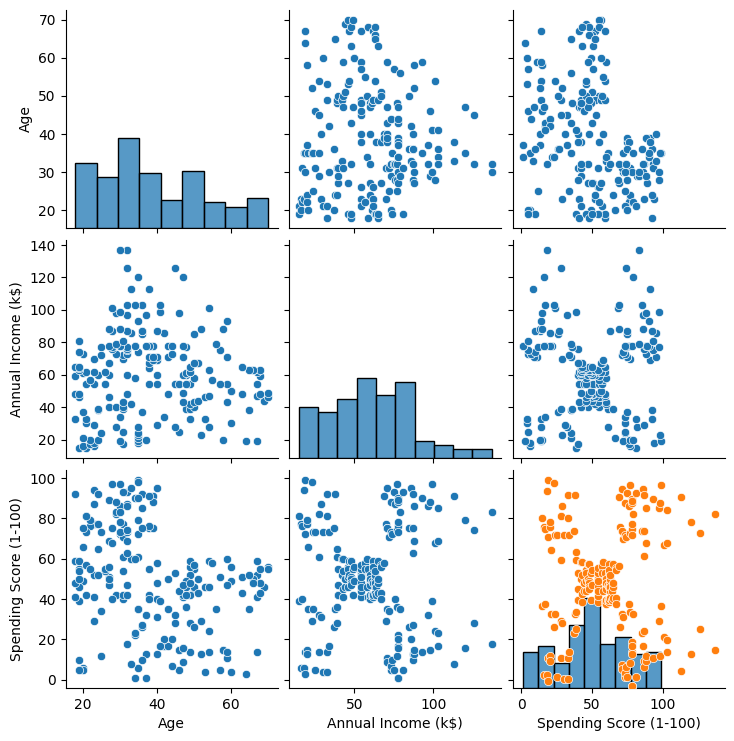

In [5]:
customer_data = customer_data.drop('CustomerID', axis=1)
sns.pairplot(customer_data)

sns.scatterplot(x=customer_data['Annual Income (k$)'],
                y=customer_data['Spending Score (1-100)'])

(200, 11)


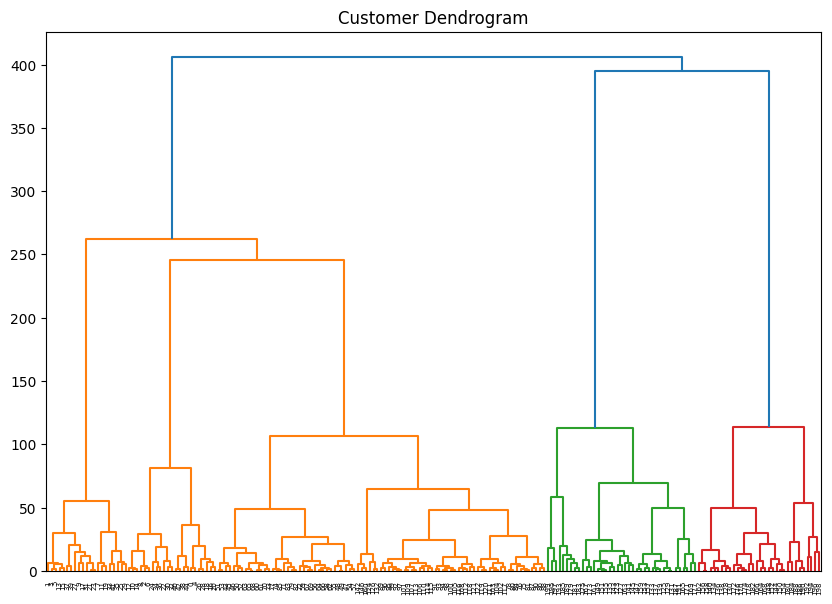

In [6]:
customer_data_oh = customer_data_oh.drop(['Age'], axis=1)
print(customer_data_oh.shape)

plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram")

selected_data = customer_data_oh.iloc[:, 1:3]
clusters = shc.linkage(selected_data,
                       method='ward',
                       metric='euclidean')
shc.dendrogram(Z=clusters)
plt.show()

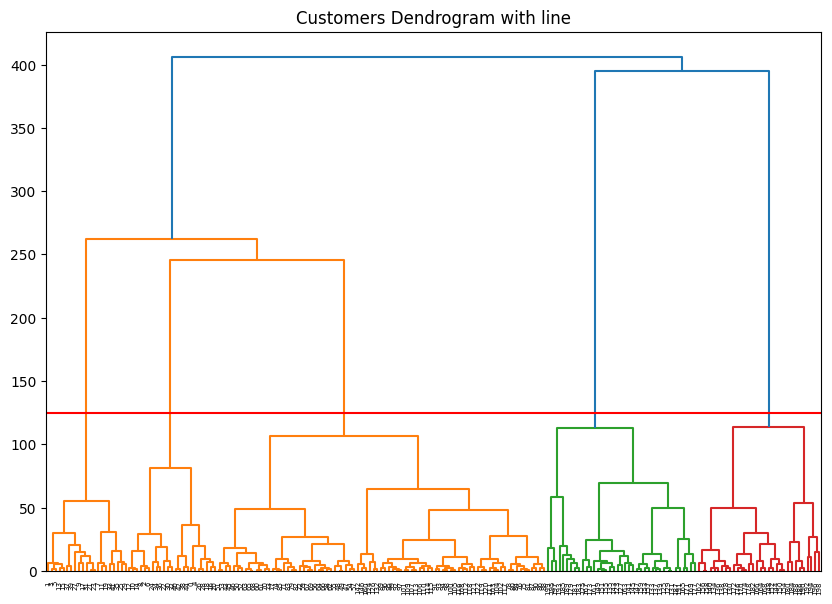

In [7]:
plt.figure(figsize=(10, 7))
plt.title("Customers Dendrogram with line")
clusters = shc.linkage(selected_data,
                       method='ward',
                       metric='euclidean')
shc.dendrogram(clusters)

plt.axhline(y = 125, color = 'r', linestyle = '-')
plt.show()

In [8]:
clustering_model = AgglomerativeClustering(n_clusters=5,
                                           metric='euclidean',
                                           linkage='ward')
clustering_model.fit(selected_data)

data_labels = clustering_model.labels_
print(data_labels)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


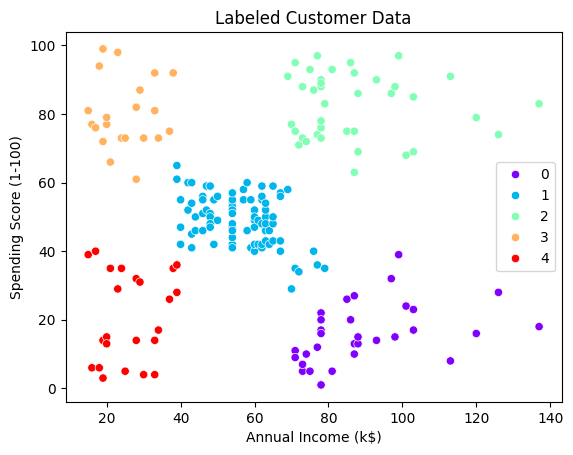

In [9]:
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=selected_data,
                hue=data_labels,
                palette="rainbow").set_title('Labeled Customer Data')
plt.show()

In [ ]:
clustering_model = AgglomerativeClustering(n_clusters=5,
                                           )

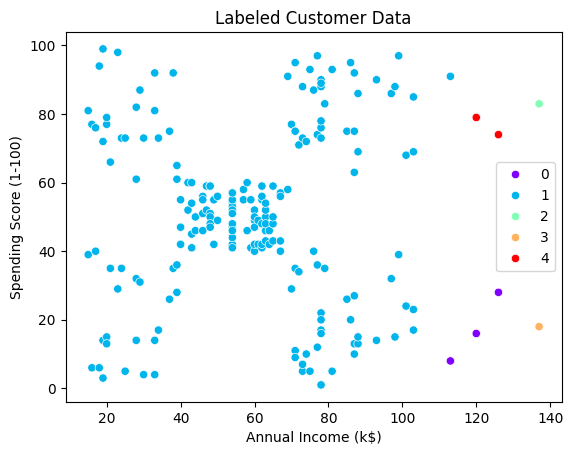

In [12]:
clustering_model = AgglomerativeClustering(n_clusters=5,
                                           linkage='single')
clustering_model.fit(selected_data)

data_labels = clustering_model.labels_

sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=selected_data,
                hue=data_labels,
                palette="rainbow").set_title('Labeled Customer Data')
plt.show()

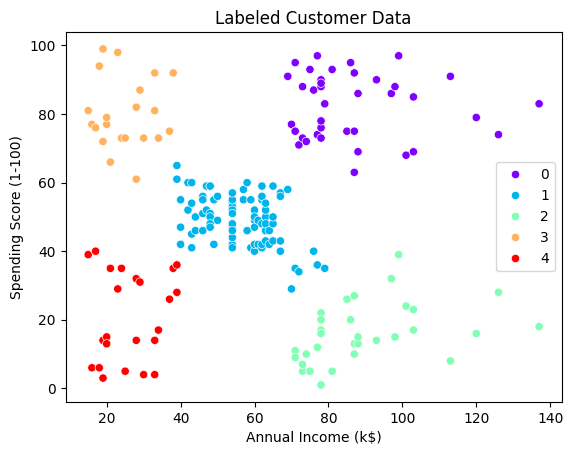

In [13]:
clustering_model = AgglomerativeClustering(n_clusters=5,
                                           linkage='complete')
clustering_model.fit(selected_data)

data_labels = clustering_model.labels_

sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=selected_data,
                hue=data_labels,
                palette="rainbow").set_title('Labeled Customer Data')
plt.show()

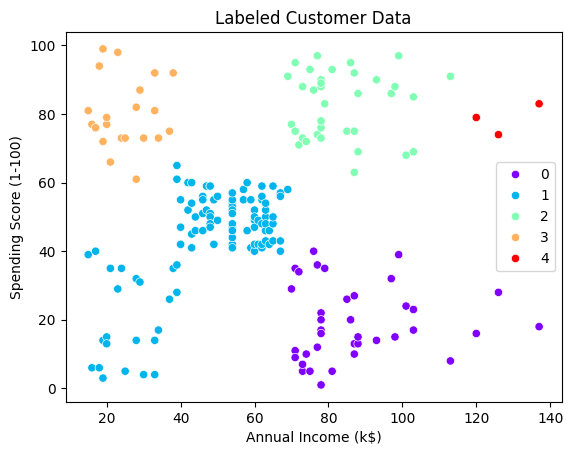

In [14]:
clustering_model = AgglomerativeClustering(n_clusters=5,
                                           linkage='average')
clustering_model.fit(selected_data)

data_labels = clustering_model.labels_

sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=selected_data,
                hue=data_labels,
                palette="rainbow").set_title('Labeled Customer Data')
plt.show()